In [9]:
import os
import numpy as np
import nibabel as nib
from scipy.fft import fft
from scipy.signal import detrend, correlate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2
import pandas as pd

In [31]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

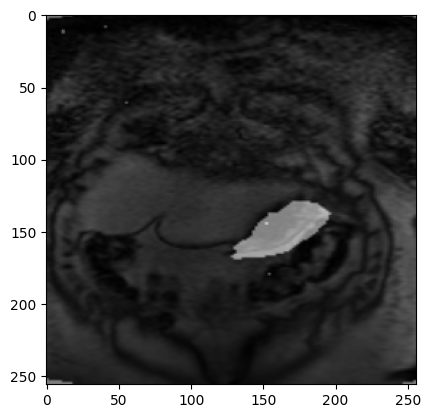

In [49]:
# --- Load NIfTI file ---
nifti_file = '/home/miguel/GI/2 - Reconstruction/Reconstructed-4D-original/FD_027/FD_027_4D_reconstructed.nii'
img = nib.load(nifti_file)
data = img.get_fdata()
num_rows, num_cols, num_slices, num_time_frames = data.shape
print('Size of data:', data.shape)  # (256, 256, Slices, TimeFrames)

# --- Cross-Sectional Area Changes ---
cross_sectional_areas = np.zeros((num_slices, num_time_frames), dtype=np.float64)

for z in range(1, num_slices + 1):
    z = 10
    slice_nonzero_history = []
    for t in range(1, num_time_frames+1)[:10]:

        path = f'/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/all-cine-mri-pngs-corrected/FD_027_time_{t}_slice_{z}_mask.png'
        image_path = f'/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/all-cine-mri-pngs-corrected/FD_027_time_{t}_slice_{z}_image.png'

        # slice_img = data[:, :, z, t]
        slice_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        fig, ax = plt.subplots()
        ax.imshow(slice_img, cmap='gray')
        ax.imshow(img.astype(np.uint8), cmap='gray', alpha=0.5)
        plt.show()
        clear_output(wait=True)
        plt.close(fig)

        # Clear the output
        

        if slice_img is None:
            print(f"Error reading image at {path}. Skipping this slice.")
            continue

            
        slice_nonzero_history.append(np.count_nonzero(slice_img))
    if np.sum(slice_nonzero_history) > 0:
        break

In [29]:
img

In [6]:
slice_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [46]:
import json
import pandas as pd
import numpy as np

In [47]:
# Load debug_results.json
path = 'debug_results.json'
with open(path, 'r') as file:
    debug_results = json.load(file)
    

In [48]:
debug_results_df = pd.DataFrame(debug_results)

In [49]:
zero_df = debug_results_df[debug_results_df['timeLag'] == 0]

In [61]:
debug_results_df[debug_results_df['timeLag'] == 0]

,sliceIdx,timeLag,xc,lags,maxIdx
8,9,0,"[0.0002810379298829617, 0.0005631628487063226,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
9,10,0,"[0.0006859316675737744, 0.0013714447196845473,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
10,11,0,"[0.001018335157569421, 0.0020356793738974736, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
11,12,0,"[0.0010906269487429988, 0.0021814662472684557,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
12,13,0,"[0.0014324459557764537, 0.002861563881796215, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
13,14,0,"[0.0013098599694431848, 0.0026217043251370365,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
14,15,0,"[0.00034144949139349373, 0.0017599866054306835...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
15,16,0,"[0.002038548553329646, 0.004631691313626211, 0...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
16,17,0,"[0.0015590179254745184, 0.0007980758266660476,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
17,18,0,"[0.0014203610700565426, 0.002183365471215244, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132


In [55]:
zero_df

,sliceIdx,timeLag,xc,lags,maxIdx
8,9,0,"[0.0002810379298829617, 0.0005631628487063226,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
9,10,0,"[0.0006859316675737744, 0.0013714447196845473,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
10,11,0,"[0.001018335157569421, 0.0020356793738974736, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
11,12,0,"[0.0010906269487429988, 0.0021814662472684557,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
12,13,0,"[0.0014324459557764537, 0.002861563881796215, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
13,14,0,"[0.0013098599694431848, 0.0026217043251370365,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
14,15,0,"[0.00034144949139349373, 0.0017599866054306835...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
15,16,0,"[0.002038548553329646, 0.004631691313626211, 0...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
16,17,0,"[0.0015590179254745184, 0.0007980758266660476,...","[-131, -130, -129, -128, -127, -126, -125, -12...",132
17,18,0,"[0.0014203610700565426, 0.002183365471215244, ...","[-131, -130, -129, -128, -127, -126, -125, -12...",132


In [50]:
np.argmax(zero_df['xc'][8])

np.int64(131)

In [51]:
np.max(zero_df['xc'][8])

np.float64(0.5375918370659002)

Text(0.5, 1.0, 'Lag values')

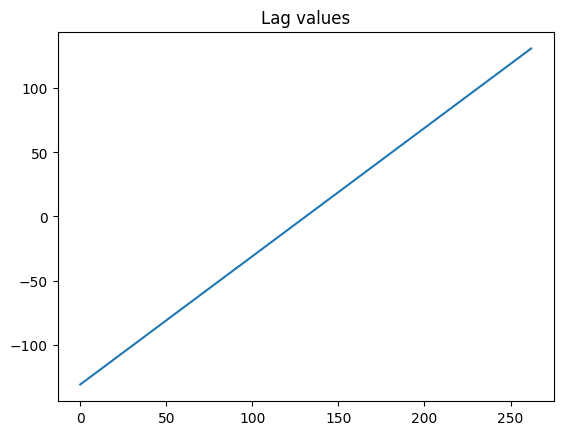

In [62]:
plt.plot(zero_df['lags'][8])
plt.title('Lag values')

In [53]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Cross-correlation values')

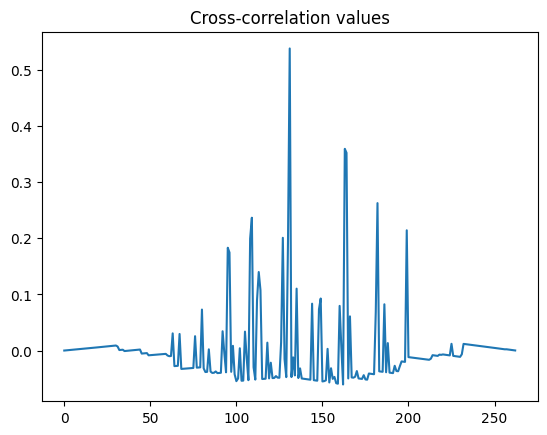

In [63]:

plt.plot(zero_df['xc'][8])
plt.title('Cross-correlation values')

In [ ]:
np.max(zero_df['xc'].values)

[0.02421863629397874,
 0.014902441673730523,
 0.02855749534776249,
 0.013505056035842854,
 0.010444021110413476,
 0.020058542267572248,
 0.019511122255656106,
 0.03489982831313811,
 0.04177550720473087,
 0.06206644505741505,
 0.03924868930851108,
 0.037961241066371554,
 0.05554552548334749,
 0.021389902496710383,
 0.059527442214516224,
 0.045606387271249535,
 0.04752764165460385,
 0.08275896138967048,
 0.053621185506260466,
 0.05298262503184536,
 0.055014687913940284,
 0.05307095277624776,
 0.06481069235962181,
 0.06660315993789497,
 0.07541974025865016,
 0.0812198903252818,
 0.09269982081731994,
 0.10926568088382306,
 0.06790456681834911,
 0.10987997641704766,
 0.07163732710321154,
 0.0584552088876234,
 0.08737721360929747,
 0.08299488336761984,
 0.09112158160391629,
 0.084195987461328,
 0.08066898590139535,
 0.04353826282430593,
 0.0749718988635222,
 0.08554216693655646,
 0.09572684074517221,
 0.13474712265094685,
 0.15338708943795695,
 0.16006630836668498,
 0.15550233740823308,
 0.1